# **Multi-class Classification CCLE**

## **Data Loading**

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns


import matplotlib.patches as mpatches

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, adjusted_rand_score, silhouette_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import matplotlib.lines as mlines
from mpl_toolkits.mplot3d import Axes3D 



from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from scipy.optimize import linear_sum_assignment


from sklearn.preprocessing import label_binarize

In [2]:
mutation = pd.read_csv('OmicsSomaticMutations.csv')
mutation = mutation[mutation.HugoSymbol == 'TP53'] # filter for TP53 mutations


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/1288859853.py:1: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation = pd.read_csv('OmicsSomaticMutations.csv')


In [3]:
mutation_subset = mutation[['ModelID', 'VariantType']] # we select only the columns we need

In [4]:
expression = pd.read_csv('OmicsExpressionProteinCodingGenesTPMLogp1.csv')
expression = expression.rename(columns={'Unnamed: 0': 'ModelID'})

In [5]:
merged_df = pd.merge(expression, mutation_subset, on='ModelID', how='inner')

In [6]:
merged_df['VariantType'].value_counts()

VariantType
SNV             932
deletion        125
insertion        33
substitution     18
Name: count, dtype: int64

In [7]:
# encode categories
le = LabelEncoder()
merged_df['VariantType'] = le.fit_transform(merged_df['VariantType'])
# check encoding
class_names={0: 'SNV', 1: 'deletion', 2: 'insertion', 3: 'substitution'}
print(class_names)
merged_df['VariantType'].value_counts()


{0: 'SNV', 1: 'deletion', 2: 'insertion', 3: 'substitution'}


VariantType
0    932
1    125
2     33
3     18
Name: count, dtype: int64

From the value counts we can see that the classes (types of mutation) are highly unbalanced, so we want to address this problem by trying resampling methods.

### Address unbalanceness: SMOTE (Synthetic Minority Over-sampling TEchnique)

At a high level, the SMOTE algorithm can be described as follows:
- Take difference between a sample and its nearest neighbour
- Multiply the difference by a random number between 0 and 1
- Add this difference to the sample to generate a new synthetic example in feature space
- Continue on with next nearest neighbour up to user-defined number

Instead of simply duplicating existing minority instances, SMOTE creates new ones by selecting a data point from the minority class and interpolating between it and one of its k-nearest neighbors. This is done by choosing a point along the line segment connecting the two instances, introducing variability and reducing the risk of overfitting. The result is a more balanced dataset that can improve the performance of classifiers on imbalanced classification problems.

Reference: https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://medium.com/%40corymaklin/synthetic-minority-over-sampling-technique-smote-7d419696b88c&ved=2ahUKEwji8PTwqaONAxVF7rsIHWA-Cc0QFnoECD4QAQ&usg=AOvVaw2qp46UR2XbUsEIXZCCdQHH

In [8]:
X = merged_df.drop(columns=['VariantType'])
X=X.set_index('ModelID')
y = merged_df['VariantType'].astype('category').cat.codes

In [9]:
sm = SMOTE(random_state=42, k_neighbors=5)

In [10]:
X_res, y_res = sm.fit_resample(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [11]:
y_res.value_counts()

0    932
1    932
3    932
2    932
Name: count, dtype: int64

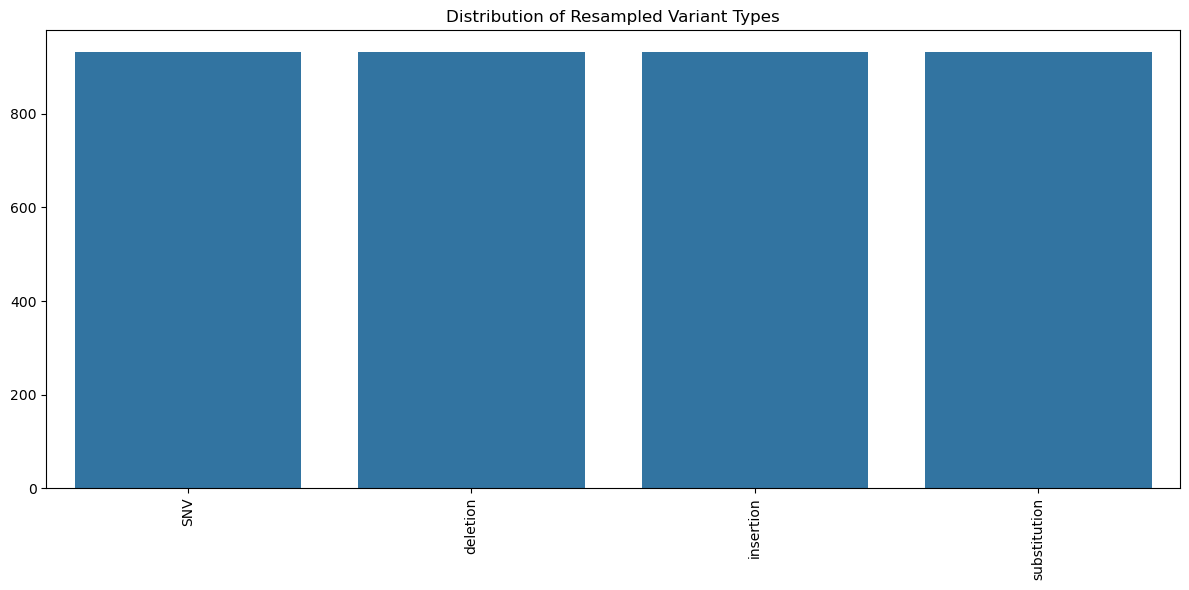

In [12]:
y_val=y_res.value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=['SNV', 'deletion', 'insertion', 'substitution'], y=y_val.values)
plt.xticks(rotation=90)
plt.title("Distribution of Resampled Variant Types")
plt.tight_layout()
plt.show()

Now, the classes are perfectly balanced but we want to check that the classifier won't overfit due to duplicates (perhaps created during resampling)

In [13]:
# we check for duplicates and count them
duplicates = X_res[X_res.duplicated()]
duplicates_count = duplicates.shape[0]
print(f"Number of duplicates in the resampled data: {duplicates_count}")


Number of duplicates in the resampled data: 153


Since we have 153 duplicates over approximately 3700 instances we try to remove them and look again at the distribution of the classes.

In [14]:
# take index of duplicates
duplicates_index = duplicates.index
duplicates_index

Index([   9,   36,   40,   41,   50,   51,   63,   75,   87,  101,
       ...
       3303, 3316, 3399, 3503, 3550, 3578, 3586, 3593, 3629, 3643],
      dtype='int64', length=153)

In [15]:
# delete duplicates
X_res = X_res.drop_duplicates()
y_res = y_res.drop(duplicates_index)
print(len(X_res))
len(y_res)

3575


3575

In [16]:
y_res.value_counts()

2    929
1    908
3    908
0    830
Name: count, dtype: int64

After deleting the duplicate rows, we can see that the classes are still balanced.

## **PCA**

We want to visualize the data before and after resampling to see how the synthetic data looks like (and whether it is reasonably created).

### **PCA before SMOTE**

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.11469922 0.06617839 0.04187325]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/3044629837.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y))))
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/3044629837.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


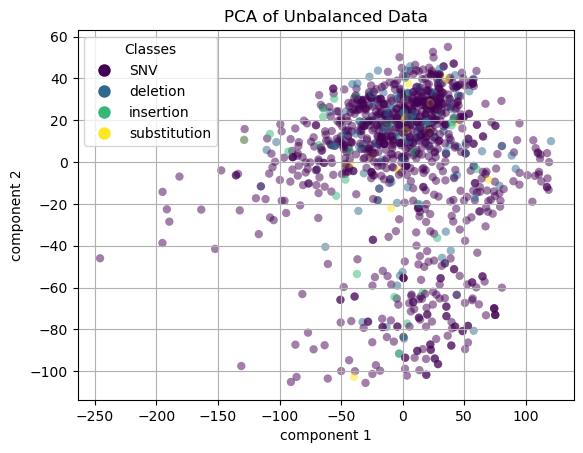

In [18]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y))))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('PCA of Unbalanced Data')

# legend for the classes
legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')
plt.grid()

plt.show()

/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/233136127.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y1, z, cmap=plt.cm.get_cmap('viridis', len(set(y))),c=y, edgecolor='none', alpha=0.5)
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/233136127.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


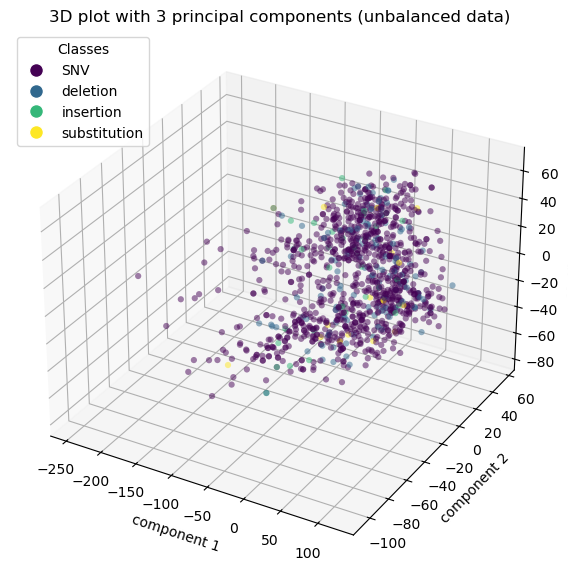

In [19]:
x=X_pca[:, 0]
y1=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")

ax.scatter3D(x, y1, z, cmap=plt.cm.get_cmap('viridis', len(set(y))),c=y, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components (unbalanced data)")
ax.set_xlabel('component 1')
ax.set_ylabel('component 2')
ax.set_zlabel('component 3')

# legend
legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')
plt.show()

In the first two images (unbalanced data), the data points appear predominantly purple with fewer points in other colors. This visual imbalance indicates that one mutation type was overrepresented in your original dataset.

### **PCA after SMOTE**

In [20]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

pca = PCA(n_components=3)  
X_pca = pca.fit_transform(X_res_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


Explained variance ratio: [0.11137742 0.07283252 0.05915741]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/1032724794.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res.values, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y_res))))
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/1032724794.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


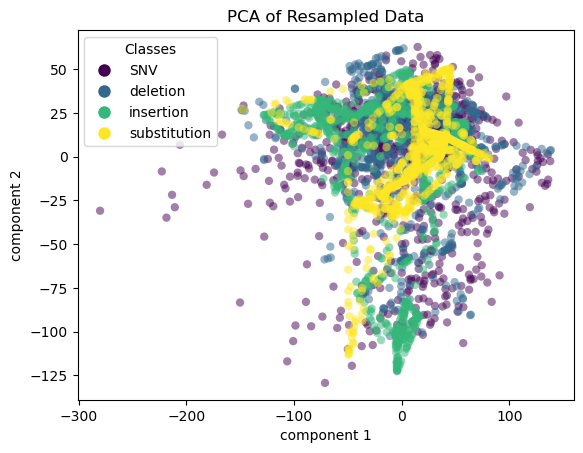

In [21]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_res.values, edgecolor='none', alpha=0.5, cmap=plt.cm.get_cmap('viridis', len(set(y_res))))
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.title('PCA of Resampled Data')
# legend
legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')

/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/3272785905.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)
/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/3272785905.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]


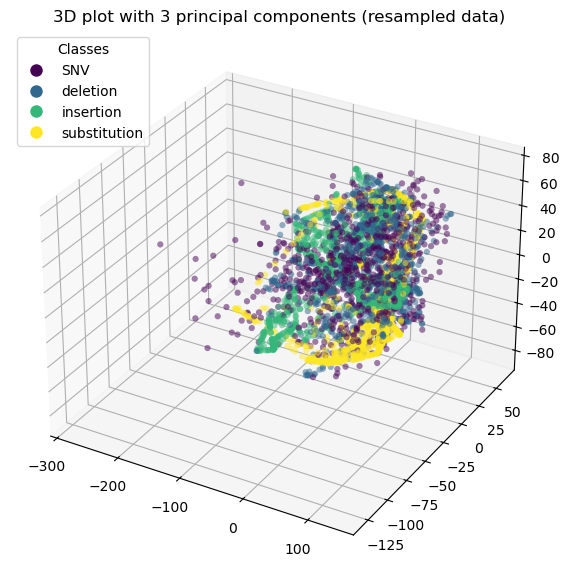

In [22]:
x=X_pca[:, 0]
y=X_pca[:, 1]
z=X_pca[:, 2]
fig= plt.figure(figsize= (10, 7))
ax = plt.axes(projection="3d")

ax.scatter3D(x, y, z, cmap=plt.cm.get_cmap('viridis', 10),c=y_res.values, edgecolor='none', alpha=0.5)
plt.title("3D plot with 3 principal components (resampled data)")
legend_elements = [mlines.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.get_cmap('viridis', len(set(y_res)))(i), markersize=10, label=f'{class_names[i]}') for i in range(4)]
plt.legend(handles=legend_elements, title='Classes', loc='upper left')
plt.show()


After resampling, the pca plots show a much more balanced color distribution, with yellow and green classes now clearly visible and forming distinct clusters. This demonstrates that SMOTE successfully generated synthetic samples for underrepresented mutation classes. In the SMOTE balanced data, there appears to be better separation between classes.

In general, the overall shape and distribution of the data cloud remains similar before and after resampling, suggesting SMOTE preserved the underlying structure of your data while addressing class imbalance.

## **Clustering**

In [23]:
y_true = y_res

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)


Accuracy: 0.4003
Adjusted Rand Index: 0.0731
Silhouette Score: 0.0832

PCA explained variance (first 2 components): [0.11137742 0.07283252]


/var/folders/r9/tk3nsgjj4_j4z3n_rxsd7s580000gn/T/ipykernel_2012/405380968.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes)


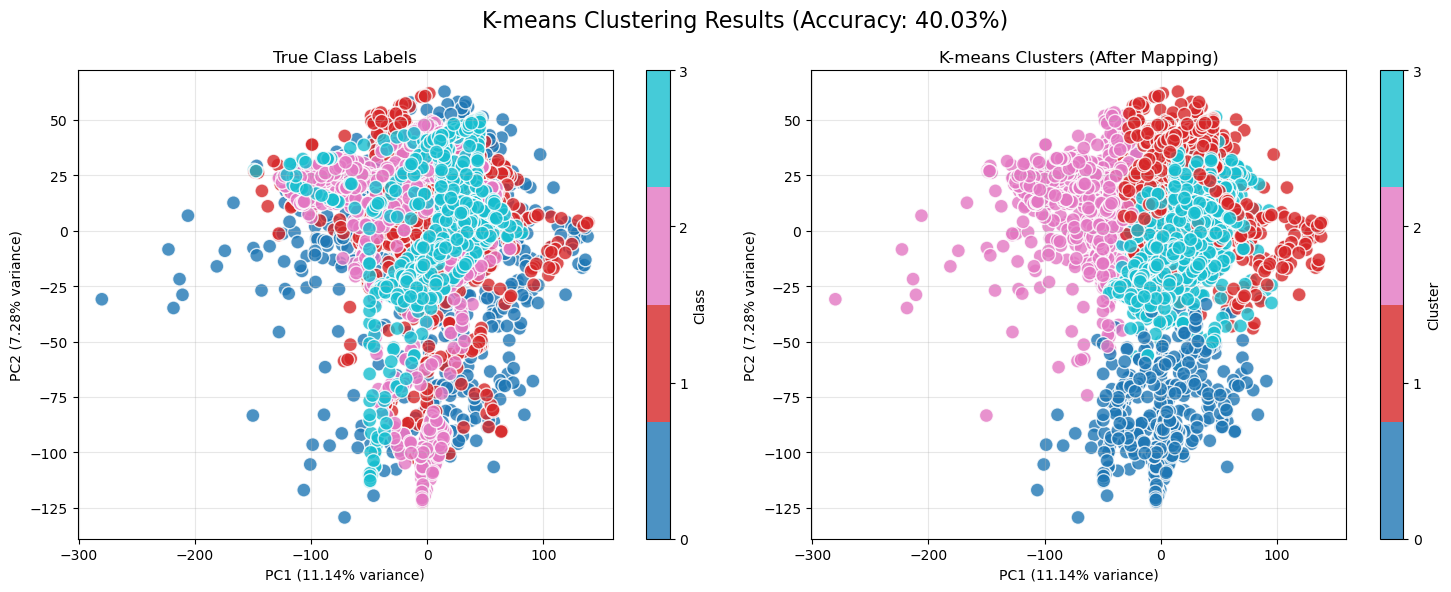

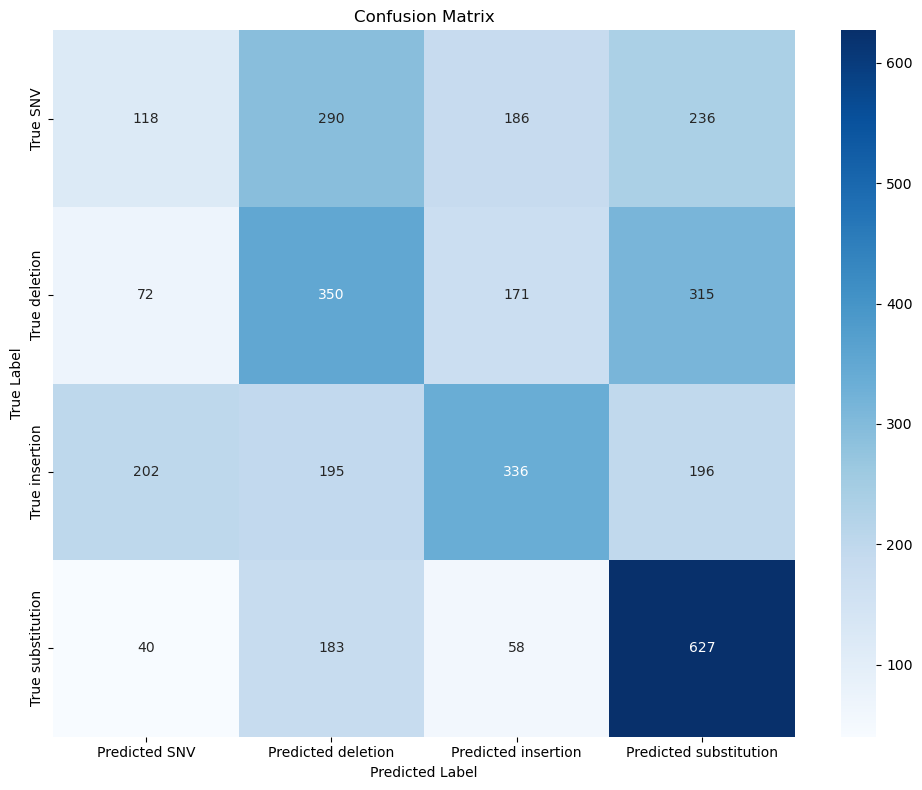

In [24]:
# k-means clustering with the same number of clusters as classes
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X_scaled)
n_classes = 4

# Function to find optimal mapping between clusters and true classes
def find_best_mapping(y_true, y_pred, n_classes):

    cm = confusion_matrix(y_true, y_pred)

    row_ind, col_ind = linear_sum_assignment(-cm)
    

    mapping = {old: new for old, new in zip(col_ind, row_ind)}
    

    y_pred_mapped = np.array([mapping[p] for p in y_pred])
    
    return y_pred_mapped, mapping


y_pred_mapped, cluster_mapping = find_best_mapping(y_true, y_pred, n_classes)


accuracy = accuracy_score(y_true, y_pred_mapped)
ari = adjusted_rand_score(y_true, y_pred)
silhouette = silhouette_score(X_scaled, y_pred)


cm = confusion_matrix(y_true, y_pred_mapped)



print(f"\nAccuracy: {accuracy:.4f}")
print(f"Adjusted Rand Index: {ari:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")


n_components = min(50, X_scaled.shape[1])  
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance (first 2 components): {pca.explained_variance_ratio_[:2]}")


cmap = plt.cm.get_cmap('tab10', n_classes)


plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap=cmap,
                      alpha=0.8, edgecolors='w', s=100)
plt.title('True Class Labels')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, label='Class', ticks=range(n_classes))
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_mapped, cmap=cmap,
                      alpha=0.8, edgecolors='w', s=100)
plt.title('K-means Clusters (After Mapping)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.colorbar(scatter, label='Cluster', ticks=range(n_classes))
plt.grid(alpha=0.3)

plt.suptitle(f'K-means Clustering Results (Accuracy: {accuracy:.2%})', fontsize=16)
plt.tight_layout()
#plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Predicted {class_names[i]}' for i in range(n_classes)],
            yticklabels=[f'True {class_names[i]}' for i in range(n_classes)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
#plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()




Conclusions from clustering:
The K-means algorithm achieved only 40.03% accuracy in identifying the true mutation classes, which is relatively low but still better than random assignment (25% for 4 classes).

This very low Silhouette score indicates that samples are not well-separated into distinct clusters. Most points likely sit near cluster boundaries, which explains the clustering difficulty.

Moreover, substitution mutations are most accurately identified (627 correctly classified). Deletions are frequently confused with other mutation types. SNVs are poorly captured by the clustering algorithm. Insertions show moderate clustering success (336 correctly classified).

## **Classifiers**

To build the classifiers we use the balanced data to prevent it to be biased towards the dominant mutation class.
First, we try and classify on the whole dataset. We try several models that are suitable for multi-class classification:
- logistic regression
- random forest (ensemble of decision trees)
- svm (finds the optimal hyperplane that maximizes the margin between classes)
- knn 
- XGBoost (implementation of Gradient Boosting and is a type of ensemble learning method)

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

this explains difference of OvR and OvO: https://medium.com/@murpanironit/a-comprehensive-guide-to-multiclass-classification-in-machine-learning-c4f893e8161d

We choose 'macro' averaging method because it gives the same importance to all the classes.
https://www.kdnuggets.com/2023/01/micro-macro-weighted-averages-f1-score-clearly-explained.html

In [49]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5), # --> performs poorly wrt the others
    'XGBoost': XGBClassifier(random_state=42),
}


all_predictions = {}
model_metrics = {
    'Accuracy': [],
    'Macro Precision': [],
    'Macro Recall': [],
    'Macro F1 Score': [],
    'Macro ROC AUC': []
}


model_names = []
confusion_matrices = {}
class_reports = {}



for name, model in models.items():
    print(f"\nTraining {name}...")
    

    model.fit(X_train_scaled, y_train)
    

    y_pred = model.predict(X_test_scaled)
    

    all_predictions[name] = y_pred
    

    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro')
    rec_macro = recall_score(y_test, y_pred, average='macro')
    f1_macro = f1_score(y_test, y_pred, average='macro')
    

    model_names.append(name)
    model_metrics['Accuracy'].append(acc)
    model_metrics['Macro Precision'].append(prec_macro)
    model_metrics['Macro Recall'].append(rec_macro)
    model_metrics['Macro F1 Score'].append(f1_macro)
    
    #  AUC ROC for multi-class (one-vs-rest)
    if n_classes > 2:

        y_proba = model.predict_proba(X_test_scaled)
        roc_auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        model_metrics['Macro ROC AUC'].append(roc_auc_macro)
    

    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices[name] = cm
    

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    class_reports[name] = report
    

    print(f"Accuracy: {acc:.4f}")
    print(f"Macro Precision: {prec_macro:.4f}")
    print(f"Macro Recall: {rec_macro:.4f}")
    print(f"Macro F1 Score: {f1_macro:.4f}")
    print(f"Macro ROC AUC: {roc_auc_macro:.4f}")


metrics_df = pd.DataFrame(model_metrics, index=model_names)
#print("\nAll model metrics:")
#print(metrics_df)




Training Logistic Regression...


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy: 0.9441
Macro Precision: 0.9473
Macro Recall: 0.9461
Macro F1 Score: 0.9433
Macro ROC AUC: 0.9912

Training Random Forest...
Accuracy: 0.9888
Macro Precision: 0.9891
Macro Recall: 0.9890
Macro F1 Score: 0.9891
Macro ROC AUC: 0.9989

Training Support Vector Machine...
Accuracy: 0.9944
Macro Precision: 0.9946
Macro Recall: 0.9945
Macro F1 Score: 0.9945
Macro ROC AUC: 0.9995

Training K-Nearest Neighbors...
Accuracy: 0.7510
Macro Precision: 0.8121
Macro Recall: 0.7605
Macro F1 Score: 0.6687
Macro ROC AUC: 0.8922

Training XGBoost...
Accuracy: 0.9860
Macro Precision: 0.9864
Macro Recall: 0.9864
Macro F1 Score: 0.9864
Macro ROC AUC: 0.9994


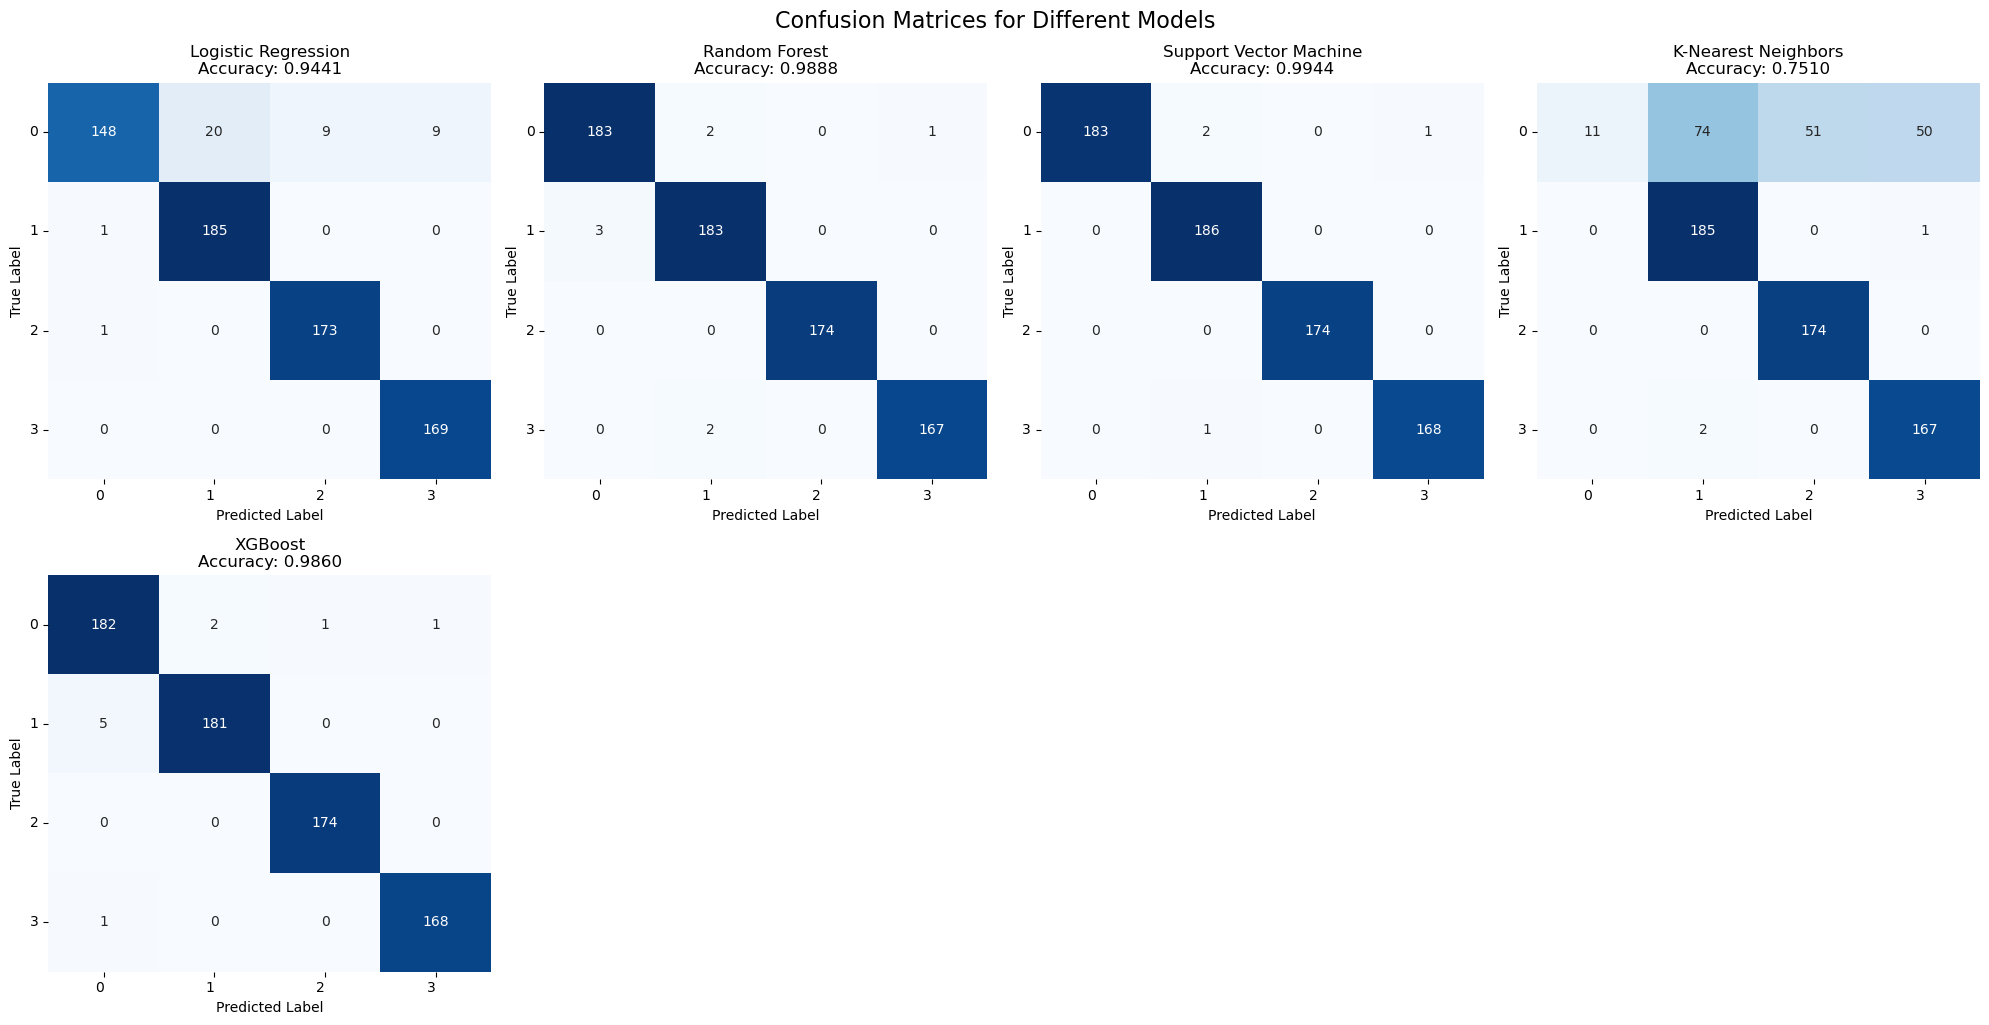

In [50]:

n_models = len(models)
rows = (n_models + 3) // 4 
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    if i < len(axes):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(f'{name}\nAccuracy: {model_metrics["Accuracy"][i]:.4f}')
        axes[i].set_xlabel('Predicted Label')
        axes[i].set_ylabel('True Label')
        axes[i].set_xticklabels(class_names, rotation=0, ha='right')
        axes[i].set_yticklabels(class_names, rotation=0)

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle('Confusion Matrices for Different Models', fontsize=16, y=1.02)
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


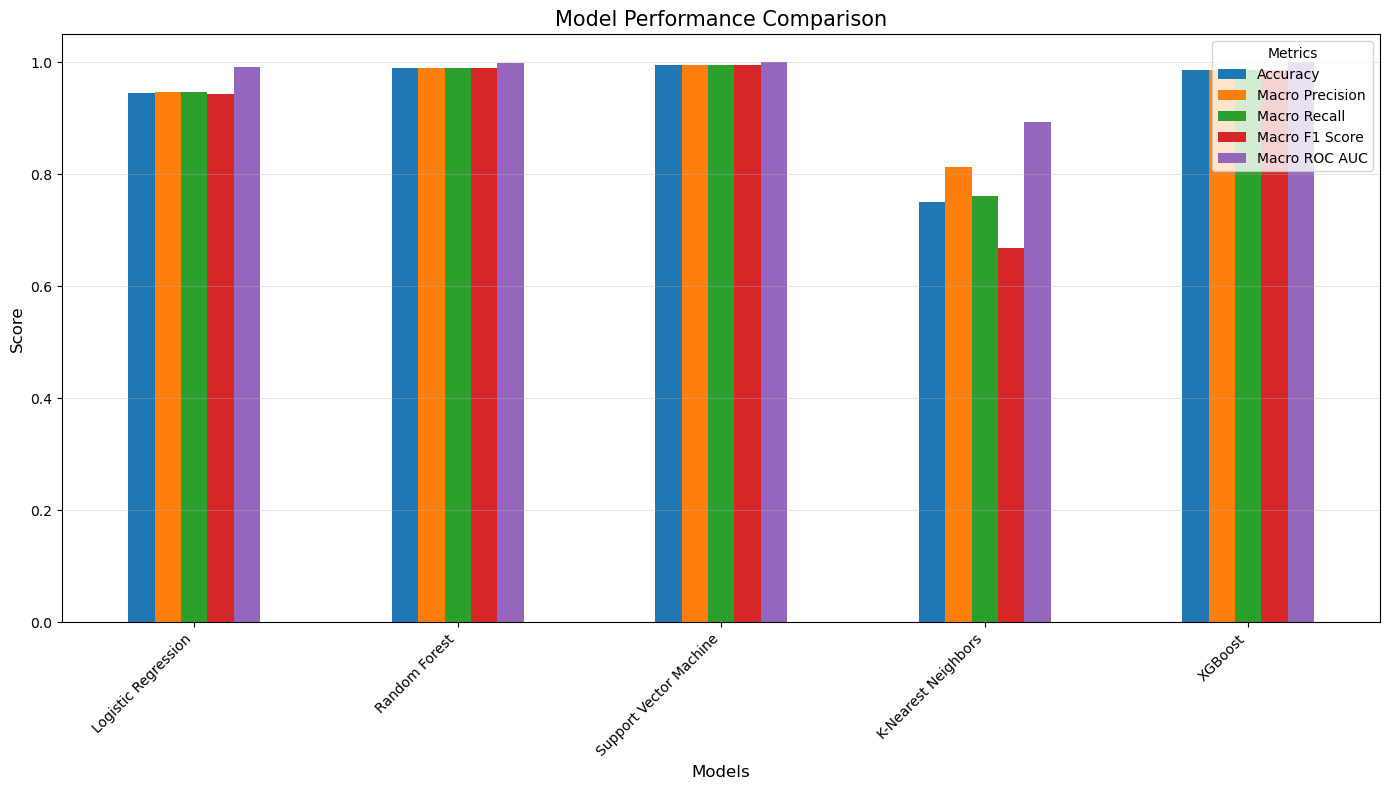

In [51]:
metrics_to_plot = list(model_metrics.keys())
metrics_df[metrics_to_plot].plot(kind='bar', figsize=(14, 8))
plt.title('Model Performance Comparison', fontsize=15)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metrics', loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300)
plt.show()


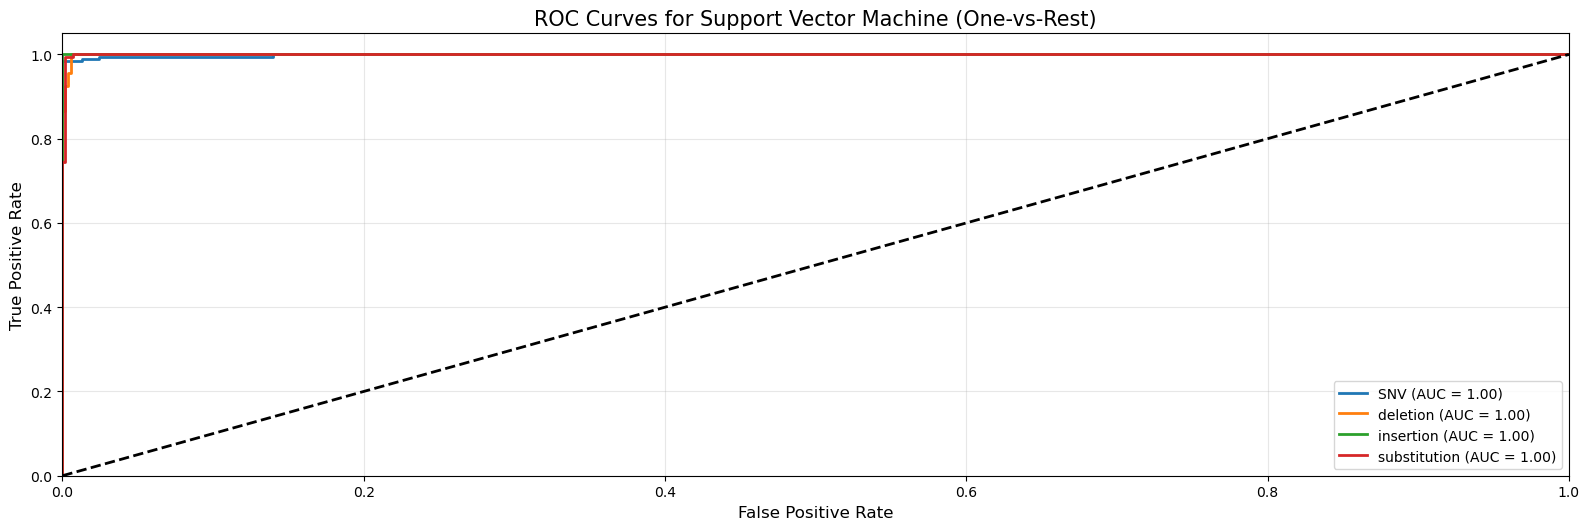

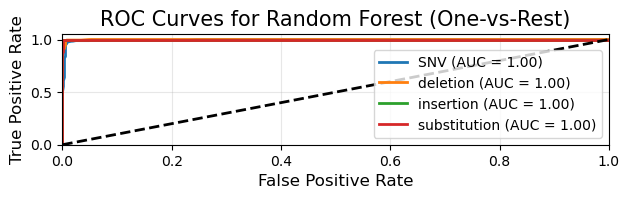

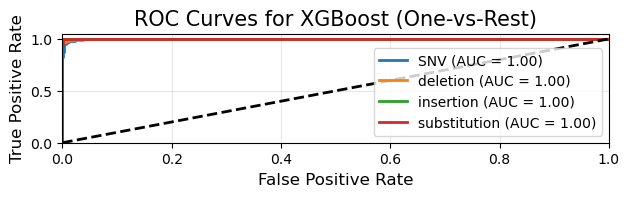

In [166]:
y_test_bin = label_binarize(y_test, classes=np.unique(y_res))

top_models = metrics_df.sort_values('Macro F1 Score', ascending=False).head(3).index

plt.figure(figsize=(16, 5 * len(top_models)))
plot_idx = 1

for model_name in top_models:
    model = models[model_name]
    y_score = model.predict_proba(X_test_scaled)
    
    plt.subplot(len(top_models), 1, plot_idx)
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        #print(f"ROC AUC for {class_names[i]}: {roc_auc:.4f}")
        plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves for {model_name} (One-vs-Rest)', fontsize=15)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    
    plot_idx += 1
    
    plt.tight_layout()
    #plt.savefig('roc_curves.png', dpi=300)
    plt.show()

In [52]:
best_models = {}
for metric in metrics_to_plot:
    best_idx = np.argmax(model_metrics[metric])
    best_models[metric] = model_names[best_idx]

print("\nBest models by metric:")
for metric, model in best_models.items():
    value = metrics_df.loc[model, metric]
    print(f"{metric}: {model} ({value:.4f})")


Best models by metric:
Accuracy: Support Vector Machine (0.9944)
Macro Precision: Support Vector Machine (0.9946)
Macro Recall: Support Vector Machine (0.9945)
Macro F1 Score: Support Vector Machine (0.9945)
Macro ROC AUC: Support Vector Machine (0.9995)


By looking at the performance of the different models, the one that emerges is SVM; thus we will perform the next analyses using exclusively that one.

## **Step2:** target genes

Now we repeat the classification task but only on a subset of features. In particular, we consider TP53 target genes (i.e. genes directly regulated by TP53).

In [53]:
target_genes = ['CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2', 'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB', 'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1', 'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1', 'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'DF15', 'DRAM1', 'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6', 'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1', 'POU3F1', 'TSGA10 DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1', 'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1', 'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2', 'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1', 'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3', 'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B', 'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4', 'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA', 'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79', 'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7', 'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF', 'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1', 'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2', 'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8', 'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1', 'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3', 'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1', 'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3', 'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1', 'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2', 'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1', 'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3', 'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA', 'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2', 'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1', 'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2', 'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15', 'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B']

In [54]:
X_res_cleaned = X_res.rename(columns=lambda x: x.split('[')[0].split('(')[0].strip())
selected_columns = [col for col in X_res_cleaned.columns if col in target_genes]
X_res_target = X_res_cleaned[selected_columns]
X_res_target

,CFLAR,CROT,ZNF195,ITGA3,SCIN,REV3L,ETV7,SEMA3B,ALOX5,FAS,...,ADGRG1,NYNRIN,SERPINB5,MYBPHL,GPX1,PLCXD2,APOBEC3C,ZNF488,DUSP14,NEFL
0,5.040454,4.274262,3.553361,7.156842,2.100978,3.555816,0.432959,1.646163,0.214125,3.642702,...,6.021035,0.014355,4.638653,0.000000,6.527633,5.350144,3.452859,1.344828,5.105594,5.531069
1,4.683135,3.092546,3.589763,6.735387,0.565597,4.372952,0.275007,5.521679,0.014355,3.106013,...,6.246028,0.263034,0.014355,0.137504,7.392060,0.495695,5.044831,0.333424,5.570159,0.687061
2,5.744430,3.423578,3.707083,7.525208,0.189034,3.263034,0.000000,1.182692,0.238787,3.577731,...,0.505891,0.097611,0.214125,0.000000,6.925406,1.137504,5.015694,0.028569,3.920293,0.084064
3,5.433293,1.867896,4.021480,8.285772,0.097611,2.531069,1.124328,3.842979,1.077243,1.992768,...,6.811471,1.150560,6.048105,0.056584,8.239073,4.040016,4.110196,4.009885,5.059182,0.042644
4,4.058316,2.918386,3.678072,7.067058,2.698218,2.855990,0.263034,1.992768,0.594549,1.333424,...,6.550593,0.014355,5.627607,0.000000,7.037272,4.072963,3.742006,1.438293,5.178316,3.135863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3723,4.557449,2.425836,3.790678,6.821632,2.519067,3.822839,0.042644,2.025621,0.204122,1.227268,...,6.196207,0.103135,0.250246,0.102884,8.600952,0.893017,4.758413,0.119060,4.820299,1.130875
3724,4.517534,2.518388,3.815744,6.593134,2.813436,3.850175,0.042644,2.173516,0.198793,1.247199,...,6.374339,0.099878,0.259656,0.103694,8.626346,0.851439,4.852351,0.114218,4.857493,1.211854
3725,4.883478,2.663022,3.832466,6.820870,0.235603,3.777586,0.342427,6.170252,0.354594,2.352281,...,5.835065,0.072297,0.326006,0.022641,8.094908,0.889961,5.178511,0.067675,4.960209,0.480826
3726,4.251870,3.290202,3.825179,4.806363,0.098102,3.964889,0.277514,0.874264,0.005612,4.541349,...,1.070611,0.492331,1.429360,0.121314,8.457506,0.276096,4.413980,0.816183,4.617355,2.280755


In [55]:
X_train_target, X_test_target, y_train_target, y_test_target = train_test_split(
    X_res_target, y_res, test_size=0.25, random_state=43, stratify=y_res
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_targ_scaled = scaler.fit_transform(X_train_target)
X_test_targ_scaled = scaler.transform(X_test_target)

In [56]:
final_model=SVC(probability=True, random_state=42)
final_model.fit(X_train_targ_scaled, y_train_target)

y_pred_target = final_model.predict(X_test_targ_scaled)
test_accuracy = accuracy_score(y_test_target, y_pred_target)
print(f"Test accuracy: {test_accuracy:.4f}")

Test accuracy: 0.9866


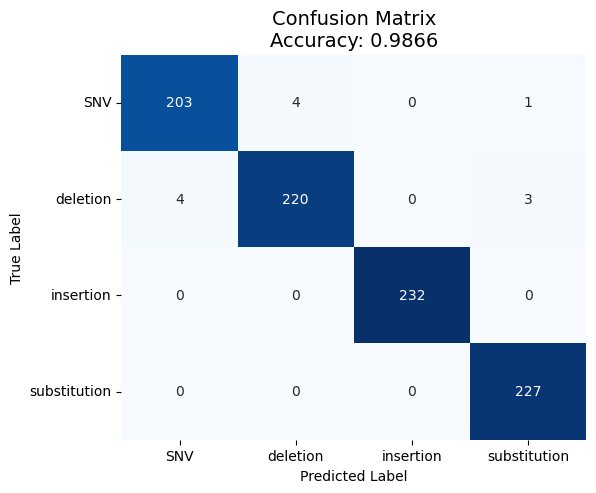

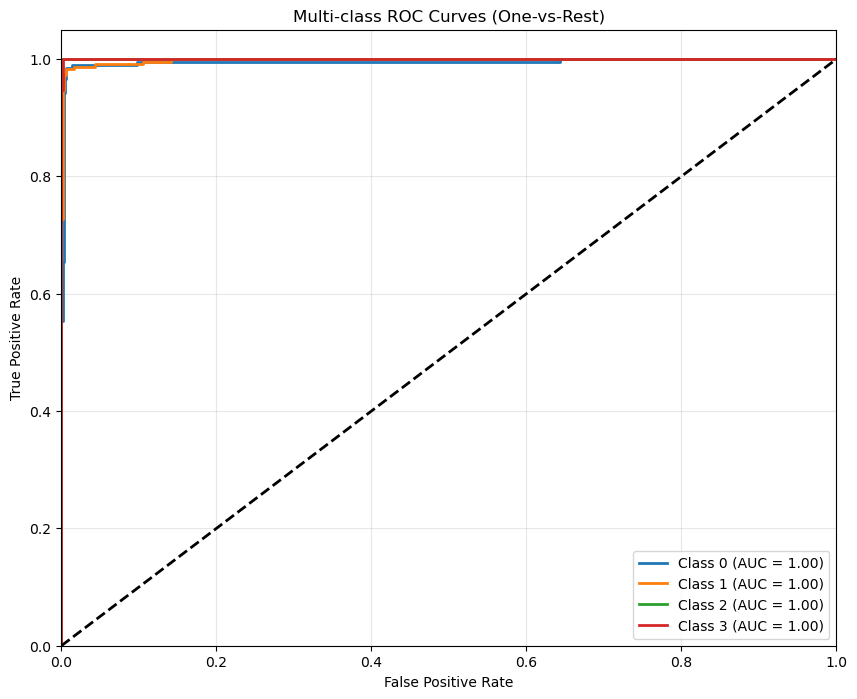

F1 Score: 0.9865
Precision: 0.9866
Recall: 0.9866
ROC AUC: 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       208
           1       0.98      0.97      0.98       227
           2       1.00      1.00      1.00       232
           3       0.98      1.00      0.99       227

    accuracy                           0.99       894
   macro avg       0.99      0.99      0.99       894
weighted avg       0.99      0.99      0.99       894



In [57]:
cm = confusion_matrix(y_test_target, y_pred_target)
acc = accuracy_score(y_test_target, y_pred_target)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
class_indices = sorted(class_names.keys())
class_labels = [class_names[i] for i in class_indices]
n_classes = len(np.unique(y_test_target))
tick_positions = np.arange(n_classes) + 0.5
plt.xticks(tick_positions, class_labels, rotation=0)
plt.yticks(tick_positions, class_labels, rotation=0)
plt.show()

y_pred_prob = final_model.predict_proba(X_test_targ_scaled)


roc_auc = roc_auc_score(y_test_target, y_pred_prob, multi_class='ovr', average='weighted')


# we binarize the output
classes = np.unique(y_test_target)
y_test_bin = label_binarize(y_test_target, classes=classes)

plt.figure(figsize=(10, 8))
for i in range(n_classes):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
            label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# more metrics
f1 = f1_score(y_test_target, y_pred_target, average='weighted')
precision = precision_score(y_test_target, y_pred_target, average='weighted')
recall = recall_score(y_test_target, y_pred_target, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


print("\nClassification Report:")
print(classification_report(y_test_target, y_pred_target))

Test accuracy is 0.9866 and also from other metrics we can tell that the performance has worsened. However, it was almost impossible to outperform the previous classification that had all the metrics above 0.99. Moreover, as said in the binary classification, now we have a significantly smaller number of features so it makes sense that we lose some performance.

## **Step3:** Statistically relevant genes

Same classifier but on statistically relevant genes (from differential expression analysis). We import statistically relevant genes from degs csv, we filter df on those and then apply same classifier as before.

In [58]:
degs = pd.read_csv('DEGs_filtered_sorted.csv')
degs = degs.rename(columns={'Unnamed: 0': 'ModelID'})
degs = degs.set_index('ModelID')

In [59]:
X_res_genes= X_res[X_res.columns.intersection(degs.index)]

Test accuracy: 0.9855


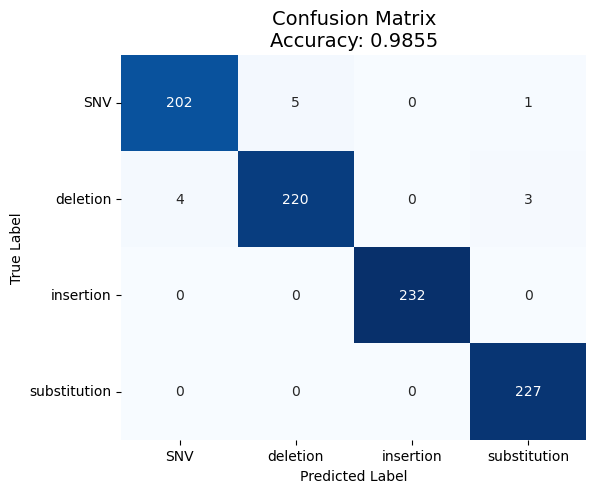

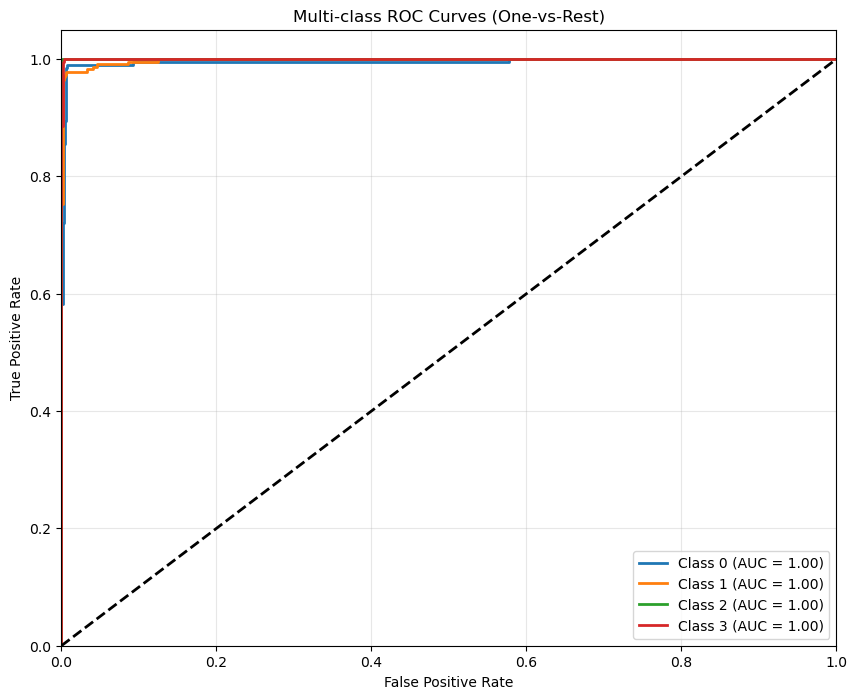

F1 Score: 0.9854
Precision: 0.9854
Recall: 0.9855
ROC AUC: 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       208
           1       0.98      0.97      0.97       227
           2       1.00      1.00      1.00       232
           3       0.98      1.00      0.99       227

    accuracy                           0.99       894
   macro avg       0.99      0.99      0.99       894
weighted avg       0.99      0.99      0.99       894



In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res_genes, y_res, test_size=0.25, random_state=43, stratify=y_res
)

# we scale the features anyway because the log2 transformation does not standardize variance across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
final_model.fit(X_train_scaled, y_train)

y_pred = final_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {test_accuracy:.4f}")


cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)


plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix\nAccuracy: {acc:.4f}', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
class_indices = sorted(class_names.keys())
class_labels = [class_names[i] for i in class_indices]
n_classes = len(np.unique(y_test_target))
tick_positions = np.arange(n_classes) + 0.5
plt.xticks(tick_positions, class_labels, rotation=0)
plt.yticks(tick_positions, class_labels, rotation=0)
plt.show()


y_pred_prob = final_model.predict_proba(X_test_scaled)  # For ROC AUC

# Multi-class ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='weighted')

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc_class = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, 
            label=f'Class {classes[i]} (AUC = {roc_auc_class:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test_target, y_pred, average='weighted')
recall = recall_score(y_test_target, y_pred, average='weighted')

print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_target, y_pred))

The prior considerations still hold for this, with the difference that this performs even worse but still achieves very good results with a test accuracy of 0.9855. This means that the classifier works very well in distinguishing the types of mutations and that, these selected genes are very significant also in this case.